## RESUMEN

En esta práctica se trabajaron conceptos básicos de Python y NumPy aplicados al manejo de vectores y matrices. Primero se crearon dos vectores y se realizaron operaciones entre ellos, como el producto escalar y la multiplicación punto a punto. También se construyó una matriz, se obtuvo su transpuesta y se utilizaron funciones de NumPy como ones, round, ceil y floor para modificar y analizar sus valores.

Después se practicó el acceso a los elementos de una matriz, obteniendo una posición específica, una fila completa y sus dimensiones mediante shape. También se generaron dos señales, una seno y otra coseno, utilizando un vector de muestras de 0 a 100. A partir de estas señales se calcularon su suma y producto, y posteriormente se graficaron para observar su comportamiento.

En la segunda parte se trabajó con señales discretas, creando funciones propias para generar el impulso unitario, el escalón y la rampa. Estas funciones permitieron construir diferentes secuencias a partir de operaciones y combinaciones de señales básicas. Los resultados se representaron mediante gráficas de tipo discreto para observar de mejor manera el comportamiento de cada secuencia.

También se construyeron señales por tramos y se calculó su derivada discreta utilizando diferencias entre muestras consecutivas. Se pudo observar que la derivada mantiene un valor constante en los tramos de rampa y presenta cambios grandes en los puntos donde existen saltos. Finalmente, se generó una secuencia más compleja mediante la concatenación de varias secuencias simples y se obtuvieron las señales x5 y x6 aplicando desplazamientos, exponenciales y funciones seno.

En general, la práctica permitió reforzar el uso de Python para el procesamiento de señales y el manejo de datos numéricos. Además, se aplicaron herramientas de NumPy y Matplotlib para realizar cálculos, generar señales y visualizar los resultados de una forma más clara.

## Funciones auxiliares para señales discretas

En esta práctica se implementaron cinco funciones de apoyo para generar y visualizar secuencias discretas elementales.


### `impseq(n0, n1, n2)` — Impulso unitario

**Qué hace:** genera la secuencia $\delta(n-n_0)$, es decir, un vector de ceros con un único 1 ubicado en la muestra $n_0$.

**Argumentos:**
- `n0`: posición donde se ubica el impulso (valor de $n$ donde $x[n]=1$).
- `n1`, `n2`: límites inferior y superior del intervalo donde se define la secuencia.

**Para qué se usa:** es la función "base" a partir de la cual se pueden construir otras señales (escalón, rampa, o combinaciones lineales de impulsos como en el punto r.a).

**Retorna:** una tupla `(x, n)` con el vector de amplitudes `x` y el vector de muestras `n`.


### `stepseq(n0, n1, n2)` — Escalón unitario

**Qué hace:** genera la secuencia $u(n-n_0)$, que vale 1 para $n \geq n_0$ y 0 para $n < n_0$.

**Argumentos:**
- `n0`: punto donde el escalón "se enciende" (pasa de 0 a 1).
- `n1`, `n2`: límites del intervalo de la secuencia.

**Para qué se usa:** para representar señales que se activan a partir de cierto instante, o como bloque para construir señales más complejas (como $x_2(n)$ y $x_4(n)$ en el punto r).

**Retorna:** `(x, n)`.


### `rampseq(n0, n1, n2, m=1)` — Rampa

**Qué hace:** genera la secuencia $r(n-n_0)$, que vale 0 antes de $n_0$ y crece linealmente con pendiente `m` a partir de $n_0$.

**Argumentos:**
- `n0`: punto donde inicia el crecimiento de la rampa.
- `n1`, `n2`: límites del intervalo de la secuencia.
- `m`: pendiente de la rampa (por defecto `1`).

**Para qué se usa:** para modelar crecimientos lineales, como en el punto s) (rampas concatenadas) o en $x_4(n)$.

**Retorna:** `(x, n)`.


### `eval_seq(n_query, n_ref, x_ref)` — Evaluador de secuencias desplazadas

**Qué hace:** dado una secuencia ya generada (`n_ref`, `x_ref`), permite consultar su valor en **cualquier** conjunto de índices `n_query`, incluso fuera del rango original — en cuyo caso asume que la señal vale 0 (fuera de su soporte).

**Argumentos:**
- `n_query`: índices donde se quiere evaluar la señal (puede incluir desplazamientos como `n-4` o `n+2`).
- `n_ref`: vector de muestras original de la señal.
- `x_ref`: vector de amplitudes original de la señal.

**Para qué se usa:** es indispensable para calcular versiones desplazadas de una señal ya construida, como $x(n-4)$ o $x(n+2)$ en el punto t), sin tener que redefinir la señal manualmente.

**Retorna:** un arreglo NumPy con los valores de la señal evaluados en `n_query`.


### `stem_plot(ax, n, x, titulo, color='b')` — Graficador de señales discretas

**Qué hace:** dibuja una secuencia discreta usando un diagrama de **tallos** (`stem`), que es la forma correcta de representar señales discretas (a diferencia de una línea continua).

**Argumentos:**
- `ax`: el eje (`Axes`) de Matplotlib donde se va a dibujar (útil para hacer subplots).
- `n`: vector de muestras (eje horizontal).
- `x`: vector de amplitudes (eje vertical).
- `titulo`: texto que aparecerá como título del gráfico.
- `color`: color de los tallos y marcadores (por defecto azul).

**Para qué se usa:** para no repetir el mismo bloque de código de graficación en cada punto del taller; centraliza el estilo (título, etiquetas de ejes, cuadrícula) en un solo lugar.

**Retorna:** no retorna nada; modifica directamente el objeto `ax` recibido.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [31]:
#a) Cree el siguiente par de vectores:
#a = [3.1,1, -0.5, -3.2, 6], b= [1, 3, 2.2, 5.1, 1]

A= np.array([3.1,1, -0.5, -3.2, 6])
B= np.array ([1, 3, 2.2, 5.1, 1])

#b) Implemente la multiplicación escalar de a.b ¿Qué se debe realizar para poder multiplicar los dos
#vectores?

#R// Para calcular el producyo escalar entre dos vectores,
#LLamamos al vector y los : significan que todos los datos van a hacer la operacion, 
# En este caso todos los datos de A y B se multiplican y se suman en la misma linea
esc= np.sum(A[:] *B[:])
print("El producto escalar entre los vectores A y B es:",esc)

#c) Implemente la multiplicación punto a punto de a.b.

mpunto= A[:]*B[:]
print("La multiplicacion punto a punto es",mpunto )

#d) Construya la siguiente matriz:

mA= np.array([[2,-1,-3],[4,1.5,-2.5],[7.3,-0.9,0.2]])
print("La matriz A es:\n", mA)

#e) Obtenga su transpuesta AT.

AT= mA.T
print("La transpuesta de la matriz A es:\n", AT)

#f) Consulte la función de los siguientes comandos de la librería numpy: ones, round, ceil, floor,
#implemente cada función para ejemplificar su uso.

# np.ones() Crea una matriz llena de unos (filas,columnas)
unos = np.ones([3, 2])

print("Matriz de unos:")
print(unos)

# np.round() edondea los valores de una matriz o un vector de decimal a los valores que quieras que queden
redondeo = np.round(mA, 1)

print("Matriz A redondeada:")
print(redondeo)

# np.ceil() redondea los valores de A hacia arriba,no importa el decimal
techo = np.ceil(mA)

print("Matriz A utilizando ceil:")
print(techo)

# np.floor() redondea los valores de A hacia abajo, no importa el decimal
piso = np.floor(A)

print("Matriz A utilizando floor:")
print(piso)

#g) Acceda al valor de la primera fila, tercera columna de la matriz A, imprímalo en consola.
val= mA[0,2]
print("el valor de la primera fila y tercer columna de la matriz es", val)

#h) Obtenga la segunda fila de dicha matriz, imprímalo en consola.
fila2= mA[1,:]
print("La segunda fila de la matriz es:\n", fila2)

#i) Consulte el comando para conocer las dimensiones de una matriz, utilícelo con la matriz A e
#imprímalo en consola.

dim = mA.shape
print("Las dimensiones de la matriz A son: ", dim)

El producto escalar entre los vectores A y B es: -5.32
La multiplicacion punto a punto es [  3.1    3.    -1.1  -16.32   6.  ]
La matriz A es:
 [[ 2.  -1.  -3. ]
 [ 4.   1.5 -2.5]
 [ 7.3 -0.9  0.2]]
La transpuesta de la matriz A es:
 [[ 2.   4.   7.3]
 [-1.   1.5 -0.9]
 [-3.  -2.5  0.2]]
Matriz de unos:
[[1. 1.]
 [1. 1.]
 [1. 1.]]
Matriz A redondeada:
[[ 2.  -1.  -3. ]
 [ 4.   1.5 -2.5]
 [ 7.3 -0.9  0.2]]
Matriz A utilizando ceil:
[[ 2. -1. -3.]
 [ 4.  2. -2.]
 [ 8. -0.  1.]]
Matriz A utilizando floor:
[ 3.  1. -1. -4.  6.]
el valor de la primera fila y tercer columna de la matriz es -3.0
La segunda fila de la matriz es:
 [ 4.   1.5 -2.5]
Las dimensiones de la matriz A son:  (3, 3)


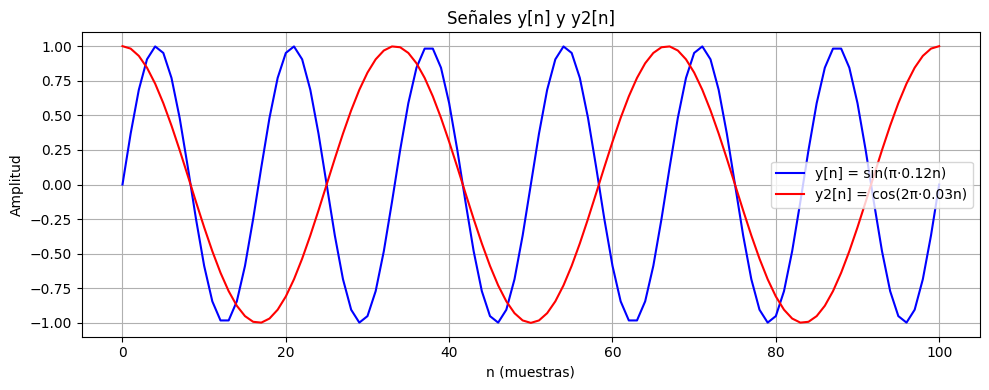

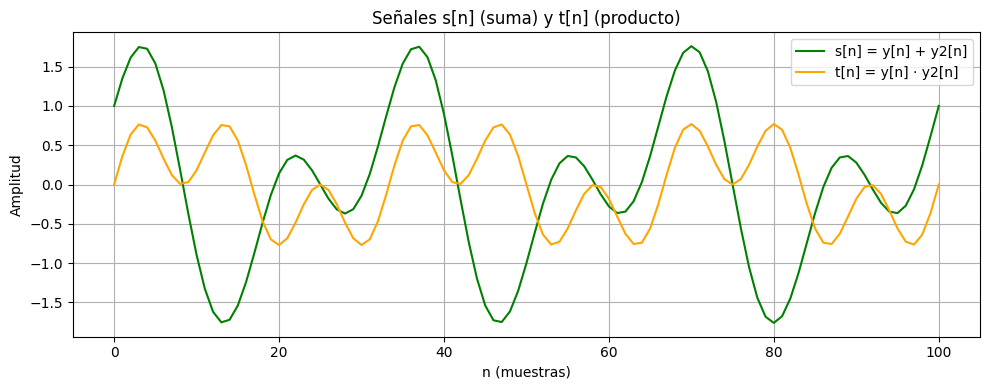

In [2]:
# j) Construir la señal y[n] = sin(pi * 0.12 * n), 0 <= n <= 100
n = np.arange(0, 101)          # vector de muestras n = 0,1,...,100
y = np.sin(np.pi * 0.12 * n)
# k) Construir la señal y2[n] = cos(2*pi * 0.03 * n)
y2 = np.cos(2 * np.pi * 0.03 * n)
# l) Suma y producto de las dos señales
s = y + y2      # suma:   s[n] = y[n] + y2[n]
t = y * y2      # producto: t[n] = y[n] * y2[n]
# m) Graficar y[n] y y2[n] en la misma figura
plt.figure(figsize=(10, 4))
plt.plot(n, y, color='blue', label='y[n] = sin(π·0.12n)')
plt.plot(n, y2, color='red', label='y2[n] = cos(2π·0.03n)')
plt.title('Señales y[n] y y2[n]')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('senales_y_y2.png', dpi=150)
plt.show()

# n) Graficar s[n] y t[n] en la misma figura
plt.figure(figsize=(10, 4))
plt.plot(n, s, color='green', label='s[n] = y[n] + y2[n]')
plt.plot(n, t, color='orange', label='t[n] = y[n] · y2[n]')
plt.title('Señales s[n] (suma) y t[n] (producto)')
plt.xlabel('n (muestras)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('senales_s_t.png', dpi=150)
plt.show()

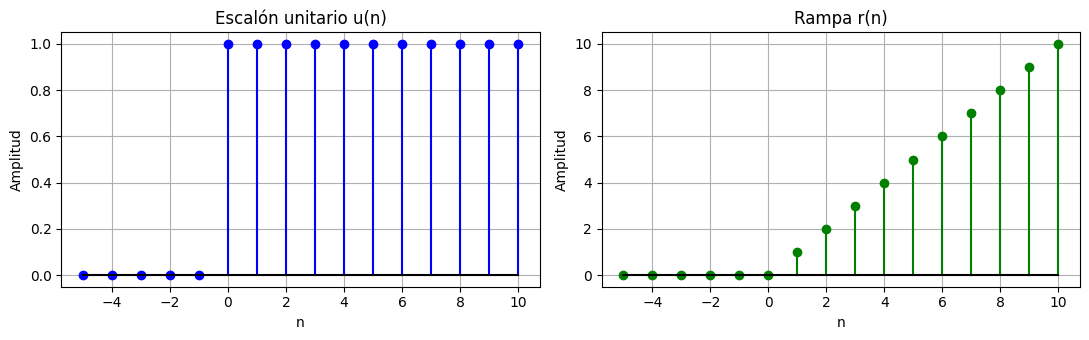

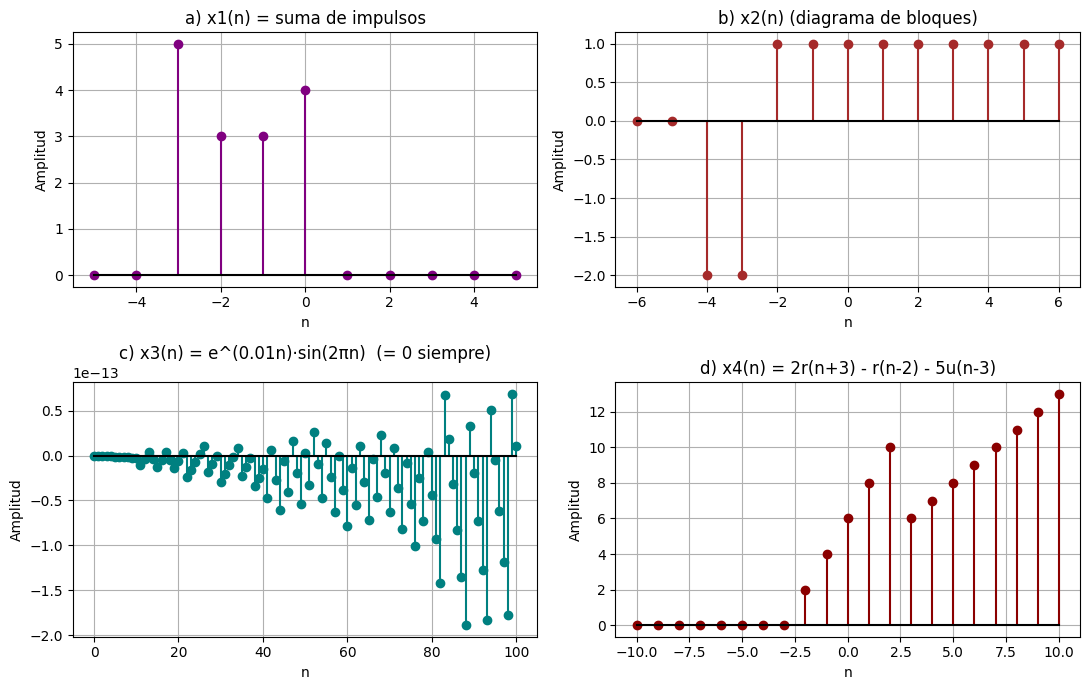

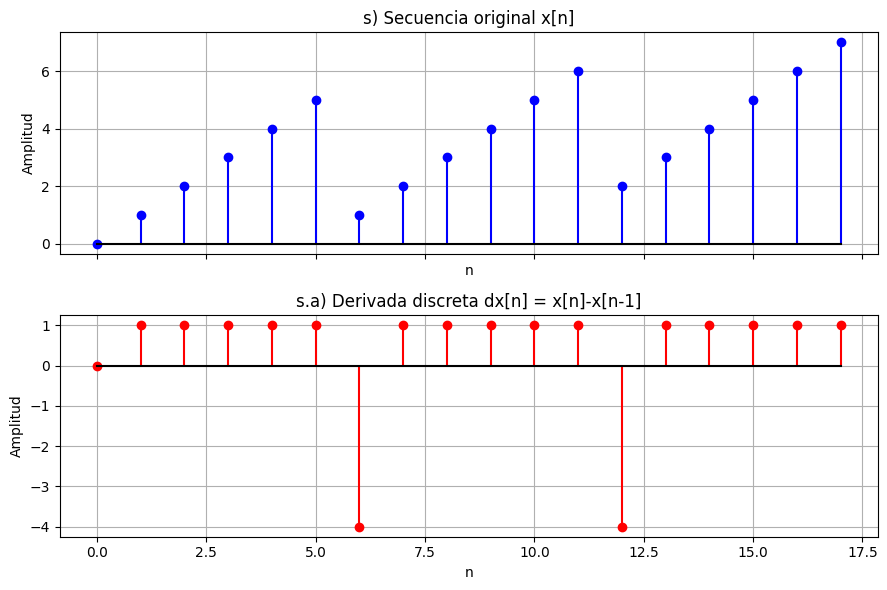

s.b) Observación sobre la derivada discreta:

La señal x[n] es una rampa que sube con pendiente 1 pero que se
"reinicia" cada 6 muestras (en n=6 y n=12), generando saltos bruscos
(discontinuidades) de 5 -> 0 en esos puntos.

Al calcular dx[n] = x[n] - x[n-1] se obtiene un valor constante de 1
dentro de cada tramo (la pendiente de la rampa), pero aparecen picos
grandes y negativos justo en n=6 y n=12, que corresponden a los saltos
de la señal original.

Esto NO es exactamente la derivada del caso continuo porque:
 - En tiempo continuo la derivada es un límite (dx/dt cuando dt->0),
   algo que no existe en una señal discreta: aquí el "paso" mínimo
   entre muestras es siempre 1, así que la diferencia hacia atrás es
   solo una APROXIMACIÓN de la derivada, no su valor exacto.
 - En los puntos de discontinuidad, la derivada continua de un salto
   sería un impulso (infinito, de área finita), mientras que la
   derivada discreta solo entrega un número finito grande
   (aquí -4), perdiendo l

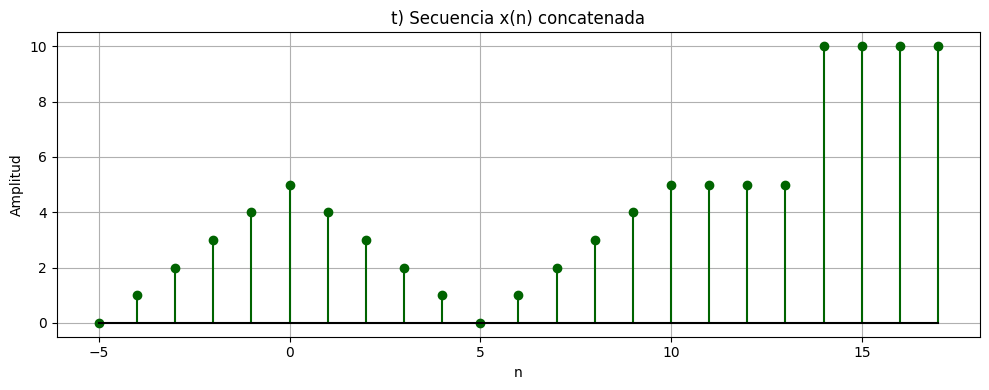

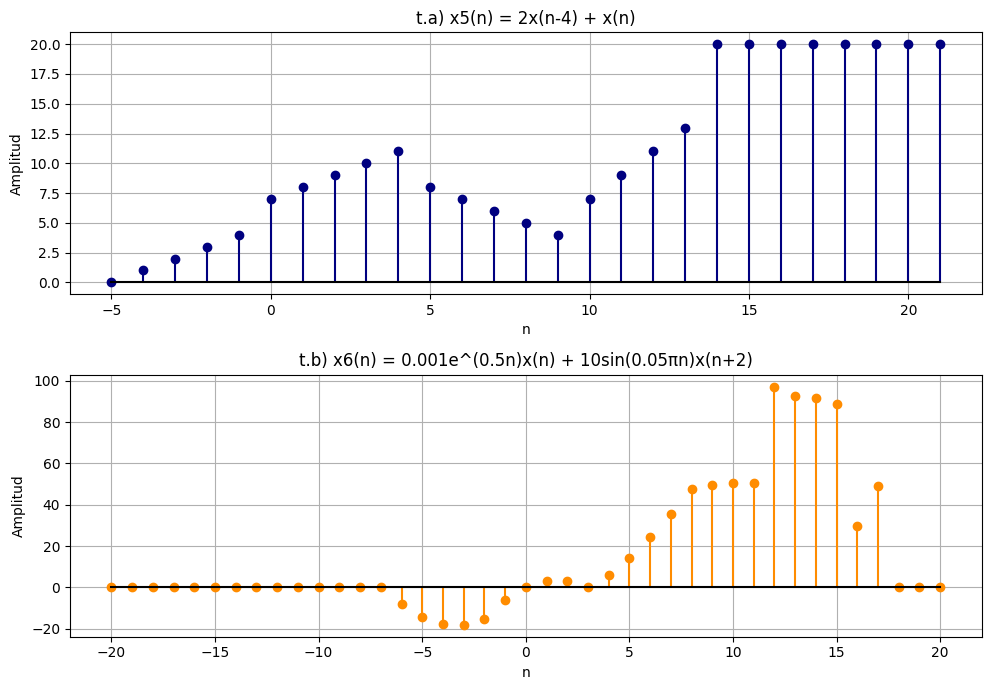

In [3]:
# PARTE 4

def impseq(n0, n1, n2):
    """Genera x(n) = delta(n-n0);  n1 <= n <= n2"""
    n = np.arange(n1, n2 + 1)
    x = ((n - n0) == 0).astype(float)
    return x, n


def stepseq(n0, n1, n2):
    """
    p) Escalón unitario u(n-n0) = 1 si n>=n0, 0 si n<n0
    definido en n1 <= n <= n2
    """
    n = np.arange(n1, n2 + 1)
    x = ((n - n0) >= 0).astype(float)
    return x, n


def rampseq(n0, n1, n2, m=1):
    """
    q) Rampa r(n-n0) = 0 si n<n0, m*(n-n0) si n>=n0
    definida en n1 <= n <= n2, con pendiente m
    """
    n = np.arange(n1, n2 + 1)
    x = np.where(n >= n0, m * (n - n0), 0.0)
    return x, n


def eval_seq(n_query, n_ref, x_ref):
    n_query = np.atleast_1d(n_query)
    tabla = dict(zip(n_ref, x_ref))
    return np.array([tabla.get(nn, 0.0) for nn in n_query], dtype=float)


def stem_plot(ax, n, x, titulo, color='b'):
    markerline, stemlines, baseline = ax.stem(n, x, basefmt='k-')
    plt.setp(markerline, color=color, marker='o')
    plt.setp(stemlines, color=color)
    ax.set_title(titulo)
    ax.set_xlabel('n')
    ax.set_ylabel('Amplitud')
    ax.grid(True)


# p) y q) Ejemplo de uso de escalón y rampa
u, nu = stepseq(0, -5, 10)
r, nr = rampseq(0, -5, 10)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
stem_plot(axs[0], nu, u, 'Escalón unitario u(n)', 'b')
stem_plot(axs[1], nr, r, 'Rampa r(n)', 'g')
plt.tight_layout()
plt.savefig('p_q_escalon_rampa.png', dpi=150)
plt.show()

# r) Generación de secuencias a partir de impulsos, escalones y rampas

# a) x1(n) = 3δ(n+1) + 5δ(n+3) + 3δ(n+2) + 3δ(n) + δ(n) 

n1, n2 = -5, 5
x1 = (3 * impseq(-1, n1, n2)[0] +
      5 * impseq(-3, n1, n2)[0] +
      3 * impseq(-2, n1, n2)[0] +
      3 * impseq(0, n1, n2)[0] +
      1 * impseq(0, n1, n2)[0])
n_x1 = impseq(0, n1, n2)[1]

# b) Sistema de diagrama de bloques
# Rama 1: u(n) * (-2)  -> Adelanto de 4   =>  -2*u(n+4)
# Rama 2: u(n) * 3     -> Adelanto de 2   =>   3*u(n+2)
# x2(n) = -2*u(n+4) + 3*u(n+2), definida entre -6 <= n <= 6
n1b, n2b = -6, 6
rama1 = -2 * stepseq(-4, n1b, n2b)[0]   # u(n-(-4)) = u(n+4)
rama2 = 3 * stepseq(-2, n1b, n2b)[0]    # u(n-(-2)) = u(n+2)
x2 = rama1 + rama2
n_x2 = stepseq(-4, n1b, n2b)[1]

# c) Sistema: x3(n) = e^(0.01n) * sin(2*pi*n), 0<=n<=100 
n_x3 = np.arange(0, 101)
x3 = np.exp(0.01 * n_x3) * np.sin(2 * np.pi * n_x3)


# d) x4(n) = 2r(n+3) - r(n-2) - 5u(n-3), -10<=n<=10 
n1d, n2d = -10, 10
x4 = (2 * rampseq(-3, n1d, n2d)[0] -
      rampseq(2, n1d, n2d)[0] -
      5 * stepseq(3, n1d, n2d)[0])
n_x4 = rampseq(-3, n1d, n2d)[1]

fig, axs = plt.subplots(2, 2, figsize=(11, 7))
stem_plot(axs[0, 0], n_x1, x1, 'a) x1(n) = suma de impulsos', 'purple')
stem_plot(axs[0, 1], n_x2, x2, 'b) x2(n) (diagrama de bloques)', 'brown')
stem_plot(axs[1, 0], n_x3, x3, 'c) x3(n) = e^(0.01n)·sin(2πn)  (= 0 siempre)', 'teal')
stem_plot(axs[1, 1], n_x4, x4, 'd) x4(n) = 2r(n+3) - r(n-2) - 5u(n-3)', 'darkred')
plt.tight_layout()
plt.savefig('r_secuencias.png', dpi=150)
plt.show()


# s) Secuencia por tramos usando rampas
#    x[n] = r[n]      0<=n<=5
#         = r[n-5]     6<=n<=11
#         = r[n-10]    12<=n<=17
n_s = np.arange(0, 18)
x_s = np.zeros_like(n_s, dtype=float)

m1 = (n_s >= 0) & (n_s <= 5)
m2 = (n_s >= 6) & (n_s <= 11)
m3 = (n_s >= 12) & (n_s <= 17)

x_s[m1] = rampseq(0, 0, 5)[0]     # r[n]
x_s[m2] = rampseq(5, 6, 11)[0]    # r[n-5]
x_s[m3] = rampseq(10, 12, 17)[0]  # r[n-10]

# s.a) Derivada (diferencia hacia atrás): dx[n] = x[n] - x[n-1]
dx_s = np.diff(x_s, prepend=0)   # se asume x[-1] = 0

fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
stem_plot(axs[0], n_s, x_s, 's) Secuencia original x[n]', 'blue')
stem_plot(axs[1], n_s, dx_s, 's.a) Derivada discreta dx[n] = x[n]-x[n-1]', 'red')
plt.tight_layout()
plt.savefig('s_derivada.png', dpi=150)
plt.show()

# s.b) Discusión (impresa en consola):
print("=" * 70)
print("s.b) Observación sobre la derivada discreta:")
print("""
La señal x[n] es una rampa que sube con pendiente 1 pero que se
"reinicia" cada 6 muestras (en n=6 y n=12), generando saltos bruscos
(discontinuidades) de 5 -> 0 en esos puntos.

Al calcular dx[n] = x[n] - x[n-1] se obtiene un valor constante de 1
dentro de cada tramo (la pendiente de la rampa), pero aparecen picos
grandes y negativos justo en n=6 y n=12, que corresponden a los saltos
de la señal original.

Esto NO es exactamente la derivada del caso continuo porque:
 - En tiempo continuo la derivada es un límite (dx/dt cuando dt->0),
   algo que no existe en una señal discreta: aquí el "paso" mínimo
   entre muestras es siempre 1, así que la diferencia hacia atrás es
   solo una APROXIMACIÓN de la derivada, no su valor exacto.
 - En los puntos de discontinuidad, la derivada continua de un salto
   sería un impulso (infinito, de área finita), mientras que la
   derivada discreta solo entrega un número finito grande
   (aquí -4), perdiendo la naturaleza impulsiva del cambio brusco.
""")

# t) Secuencia x(n) generada concatenando secuencias simples
#    x(n) = {0,1,2,3,4,5^,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10}
#    (el sombrero indica que ese valor corresponde a n=0)

# Tramo 1: rampa ascendente,        n = -5 .. 0   -> 0,1,2,3,4,5
n_a, x_a = rampseq(-5, -5, 0)[1], rampseq(-5, -5, 0)[0]

# Tramo 2: rampa descendente,       n =  1 .. 5   -> 4,3,2,1,0
n_b = np.arange(1, 6)
x_b = 5 - rampseq(0, 1, 5)[0]

# Tramo 3: rampa ascendente,        n =  6 .. 10  -> 1,2,3,4,5
n_c, x_c = rampseq(5, 6, 10)[1], rampseq(5, 6, 10)[0]

# Tramo 4: constante = 5,           n = 11 .. 13
n_d = np.arange(11, 14)
x_d = 5 * np.ones_like(n_d, dtype=float)

# Tramo 5: constante = 10,          n = 14 .. 17
n_e = np.arange(14, 18)
x_e = 10 * np.ones_like(n_e, dtype=float)

n_t = np.concatenate([n_a, n_b, n_c, n_d, n_e])
x_t = np.concatenate([x_a, x_b, x_c, x_d, x_e])

fig, ax = plt.subplots(figsize=(10, 4))
stem_plot(ax, n_t, x_t, 't) Secuencia x(n) concatenada', 'darkgreen')
plt.tight_layout()
plt.savefig('t_secuencia_concatenada.png', dpi=150)
plt.show()

# t.a) x5(n) = 2x(n-4) + x(n) 
n_x5 = np.arange(n_t.min(), n_t.max() + 4 + 1)   # rango extendido para cubrir el desfase
x_shift4 = eval_seq(n_x5 - 4, n_t, x_t)          # x(n-4)
x_orig_x5 = eval_seq(n_x5, n_t, x_t)             # x(n)
x5 = 2 * x_shift4 + x_orig_x5

# t.b) x6(n) = 0.001*e^(0.5n)*x(n) + 10*sin(0.05*pi*n)*x(n+2), -20<=n<=20 
n_x6 = np.arange(-20, 21)
x_n = eval_seq(n_x6, n_t, x_t)          # x(n)
x_n2 = eval_seq(n_x6 + 2, n_t, x_t)     # x(n+2)
x6 = 0.001 * np.exp(0.5 * n_x6) * x_n + 10 * np.sin(0.05 * np.pi * n_x6) * x_n2

fig, axs = plt.subplots(2, 1, figsize=(10, 7))
stem_plot(axs[0], n_x5, x5, 't.a) x5(n) = 2x(n-4) + x(n)', 'navy')
stem_plot(axs[1], n_x6, x6, 't.b) x6(n) = 0.001e^(0.5n)x(n) + 10sin(0.05πn)x(n+2)', 'darkorange')
plt.tight_layout()
plt.savefig('t_x5_x6.png', dpi=150)
plt.show()